In [2]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [12]:
# Import library to handle data
import pandas as pd

# Load dataset from CSV file
data = pd.read_csv("data.csv")

# Print dataset size (rows, columns)
print("Shape:", data.shape)

# Display first 5 rows to inspect data
print("\nFirst 5 rows:")
print(data.head())

# Separate features (X) and labels (y)
# Features = all gene columns (skip first 2 columns)
X = data.iloc[:, 2:]                 # your features (data)
feature_names = X.columns

# Labels = 'type' column
y = data['type']

# Check how many samples in each class
print("\nClass distribution:")
print(y.value_counts())

Shape: (151, 54677)

First 5 rows:
   samples   type  1007_s_at   1053_at    117_at    121_at  1255_g_at  \
0       84  basal   9.850040  8.097927  6.424728  7.353027   3.029122   
1       85  basal   9.861357  8.212222  7.062593  7.685578   3.149468   
2       87  basal  10.103478  8.936137  5.735970  7.687822   3.125931   
3       90  basal   9.756875  7.357148  6.479183  6.986624   3.181638   
4       91  basal   9.408330  7.746404  6.693980  7.333426   3.169923   

    1294_at   1316_at   1320_at  ...  AFFX-r2-Ec-bioD-3_at  \
0  6.880079  4.963740  4.408328  ...             12.229711   
1  7.542283  5.129607  4.584418  ...             12.178531   
2  6.562369  4.813449  4.425195  ...             12.125108   
3  7.802344  5.490982  4.567956  ...             12.111235   
4  7.610457  5.372469  4.424426  ...             12.173642   

   AFFX-r2-Ec-bioD-5_at  AFFX-r2-P1-cre-3_at  AFFX-r2-P1-cre-5_at  \
0             11.852955            13.658701            13.477698   
1             1

In [5]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# 1. LOAD DATA (Module 1: Dataset Selection)
# Your screenshot shows the file is named 'data.csv'
data = pd.read_csv('data.csv')

# 2. SEPARATE FEATURES AND LABELS
# Based on your screenshot: features start from column 2, labels are in 'type'
X = data.iloc[:, 2:]  # Features: skip first 2 columns [cite: 69]
y = data['type']      # Target: 'type' column (tumor vs. normal) [cite: 63]

# 3. SPLIT DATA
# We use 'stratify=y' to maintain class balance for clinical reliability[cite: 86, 106].
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. PREPROCESSING (Module 2)
# Standardizing prevents high-dimensional gene features from dominating the model[cite: 67, 154].
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. TRAIN BASELINE MODEL (Module 4)
# Logistic Regression with L2 regularization to prevent overfitting[cite: 72, 146].
model = LogisticRegression(max_iter=1000, penalty='l2')
model.fit(X_train, y_train)

# 6. EVALUATION (Module 7)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Baseline Accuracy: 0.9032

Confusion Matrix:
 [[6 0 0 0 0 0]
 [0 7 0 0 0 1]
 [0 0 3 0 0 0]
 [0 0 0 5 1 0]
 [0 0 0 0 6 0]
 [0 0 0 1 0 1]]

Classification Report:
               precision    recall  f1-score   support

         HER       1.00      1.00      1.00         6
       basal       1.00      0.88      0.93         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       0.83      0.83      0.83         6
   luminal_B       0.86      1.00      0.92         6
      normal       0.50      0.50      0.50         2

    accuracy                           0.90        31
   macro avg       0.87      0.87      0.86        31
weighted avg       0.91      0.90      0.90        31



In [7]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. STRATIFIED K-FOLD (better for small + imbalanced data)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_model_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'   # 🔥 important for your "normal" class
)

cv_scores = cross_val_score(rf_model_balanced, X_train, y_train, cv=cv)

print("Stratified K-Fold Scores:", cv_scores)
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

# 2. Train + Evaluate
rf_model_balanced.fit(X_train, y_train)

rf_pred_balanced = rf_model_balanced.predict(X_test)

print(f"\nBalanced RF Accuracy: {accuracy_score(y_test, rf_pred_balanced):.4f}")
print("\nBalanced RF Classification Report:\n", classification_report(y_test, rf_pred_balanced))

Stratified K-Fold Scores: [1.         0.83333333 1.         0.95833333 0.95833333]
Mean Accuracy: 0.9500
Std Dev: 0.0612

Balanced RF Accuracy: 0.9355

Balanced RF Classification Report:
               precision    recall  f1-score   support

         HER       1.00      1.00      1.00         6
       basal       1.00      1.00      1.00         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       0.83      0.83      0.83         6
   luminal_B       0.86      1.00      0.92         6
      normal       1.00      0.50      0.67         2

    accuracy                           0.94        31
   macro avg       0.95      0.89      0.90        31
weighted avg       0.94      0.94      0.93        31



In [8]:
rf_model_balanced.fit(X_train, y_train)
rf_pred_balanced = rf_model_balanced.predict(X_test)

Saving data.csv to data.csv
Uploaded files: ['data.csv']

Dataset columns:
Index(['samples', 'type', '1007_s_at', '1053_at', '117_at', '121_at',
       '1255_g_at', '1294_at', '1316_at', '1320_at',
       ...
       'AFFX-r2-Ec-bioD-3_at', 'AFFX-r2-Ec-bioD-5_at', 'AFFX-r2-P1-cre-3_at',
       'AFFX-r2-P1-cre-5_at', 'AFFX-ThrX-3_at', 'AFFX-ThrX-5_at',
       'AFFX-ThrX-M_at', 'AFFX-TrpnX-3_at', 'AFFX-TrpnX-5_at',
       'AFFX-TrpnX-M_at'],
      dtype='object', length=54677)


/tmp/ipykernel_4221/3419543903.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


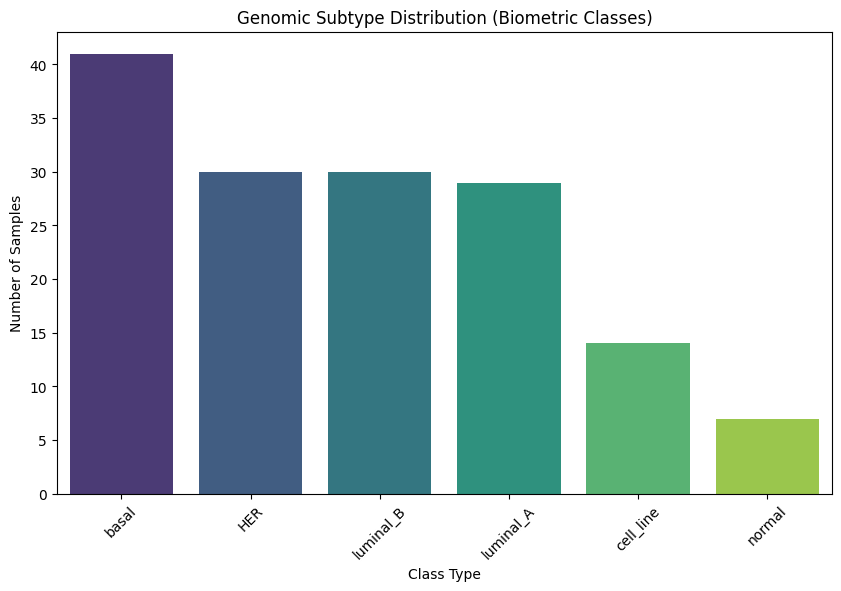


Saved files:
['.config', 'fig1.pdf', 'data.csv', 'fig1.png', 'sample_data']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Skipping metrics because y_test or rf_pred_balanced is not defined yet.


In [5]:
# =========================
# COMPLETE WORKING CODE
# =========================

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# =========================
# STEP 1: UPLOAD YOUR CSV
# =========================
from google.colab import files
uploaded = files.upload()

# show uploaded filenames
print("Uploaded files:", list(uploaded.keys()))

# put your uploaded CSV name here
filename = list(uploaded.keys())[0]

# load dataset
data = pd.read_csv(filename)

# =========================
# STEP 2: CHECK COLUMNS
# =========================
print("\nDataset columns:")
print(data.columns)

# change this if your label column is not called 'type'
target_column = 'type'

# =========================
# STEP 3: PLOT AND SAVE FIGURE
# =========================
plt.figure(figsize=(10, 6))

sns.countplot(
    data=data,
    x=target_column,
    palette='viridis',
    order=data[target_column].value_counts().index
)

plt.title("Genomic Subtype Distribution (Biometric Classes)")
plt.ylabel("Number of Samples")
plt.xlabel("Class Type")
plt.xticks(rotation=45)

plt.savefig("fig1.pdf", bbox_inches="tight")
plt.savefig("fig1.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close()
print("\nSaved files:")
print(os.listdir())

# download the PDF for Overleaf
files.download("fig1.pdf")

# =========================
# STEP 4: OPTIONAL METRICS
# =========================
# Only run this part if y_test and rf_pred_balanced already exist

try:
    cm_balanced = confusion_matrix(y_test, rf_pred_balanced)

    FP = cm_balanced.sum(axis=0) - np.diag(cm_balanced)
    FN = cm_balanced.sum(axis=1) - np.diag(cm_balanced)
    TP = np.diag(cm_balanced)
    TN = cm_balanced.sum() - (FP + FN + TP)

    far = FP.sum() / (FP.sum() + TN.sum())
    frr = FN.sum() / (FN.sum() + TP.sum())

    print("\n--- BIOMETRIC SECURITY CHECKPOINT METRICS ---")
    print(f"False Acceptance Rate (FAR): {far:.4f}")
    print(f"False Rejection Rate (FRR): {frr:.4f}")
    print(f"Equal Error Rate (EER): {(far + frr) / 2:.4f}")

except NameError:
    print("\nSkipping metrics because y_test or rf_pred_balanced is not defined yet.")